# 03 — Regime-Conditioned Risk

This notebook asks whether the detected regimes correspond to materially different risk profiles.

The central research question is:

> Do the estimated regimes identify different covariance, correlation, drawdown, and tail-risk environments?

This notebook does not optimize a strategy. It validates whether regime awareness is meaningful from a risk-estimation perspective.

## Research objective

Validate the regime labels produced by `02_regime_detection.ipynb` before using them in allocation.

The notebook should answer:

- Are the regime labels loaded correctly?
- Are all expected regimes present?
- Are regime sample sizes large enough for risk estimation?
- Do volatility, CVaR, drawdown, and correlation differ across regimes?
- Are regime-conditioned covariance and correlation estimates reliable enough to inform allocation?

## Expected local outputs

Core outputs:

- `data/processed/regime_risk_summary.csv`
- `data/processed/regime_correlation_long.csv`
- `data/processed/regime_covariance_long.csv`

Diagnostic outputs:

- `data/processed/regime_label_audit.csv`
- `data/processed/regime_sample_reliability.csv`
- `data/processed/unconditional_risk_summary.csv`
- `data/processed/regime_return_quantiles.csv`
- `data/processed/regime_conditioned_risk_manifest.csv`

Figures:

- `reports/figures/03_regime_risk_bars.png`
- `reports/figures/03_regime_return_distributions.png`
- `reports/figures/03_regime_correlation_heatmaps.png`

Interpretation rule:

> Regime-conditioned risk estimates are useful only if the loaded regime labels are valid and each regime has enough observations to support stable estimation.

## 0. Path and artifact check

This notebook depends on processed outputs generated by previous notebooks.

Required upstream files:

- `data/processed/returns.csv`
- `data/processed/regime_labels.csv`

If this check fails, rerun:

1. `01_data_pipeline.ipynb`
2. `02_regime_detection.ipynb`

In [16]:
required_files = [
    DATA_DIR / "returns.csv",
    DATA_DIR / "regime_labels.csv",
]

missing_files = [path for path in required_files if not path.exists()]

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

if missing_files:
    print("Missing required files:")
    for path in missing_files:
        print("-", path)
    raise FileNotFoundError(
        "Missing upstream processed files. "
        "Rerun 01_data_pipeline.ipynb and 02_regime_detection.ipynb from top to bottom."
    )

print("All required upstream files are available.")

Project root: /workspaces/regime-aware-portfolio-risk-allocation
Data directory: /workspaces/regime-aware-portfolio-risk-allocation/data/processed
All required upstream files are available.


In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", "{:,.4f}".format)

In [7]:
from regime_portfolio.metrics import performance_summary
from regime_portfolio.regimes import regime_durations
from regime_portfolio.risk import (
    correlation_by_regime,
    covariance_by_regime,
    drawdown_series,
    regime_risk_summary,
)

In [8]:
returns = pd.read_csv(DATA_DIR / "returns.csv", index_col=0, parse_dates=True)
regimes = pd.read_csv(DATA_DIR / "regime_labels.csv", index_col=0, parse_dates=True)["regime"]

# Optional diagnostic file created by notebook 02.
regime_interpretation_path = DATA_DIR / "regime_interpretation.csv"
if regime_interpretation_path.exists():
    regime_interpretation_from_notebook_02 = pd.read_csv(regime_interpretation_path, index_col=0)
else:
    regime_interpretation_from_notebook_02 = None

aligned = returns.join(regimes.rename("regime"), how="inner").dropna()

returns_aligned = aligned[returns.columns]
regimes_aligned = aligned["regime"].astype(int)

regime_counts = regimes_aligned.value_counts().sort_index().rename("n_obs")
regime_shares = (regime_counts / regime_counts.sum()).rename("sample_share")

expected_regimes = pd.Index([0, 1, 2], name="regime")
observed_regimes = pd.Index(sorted(regimes_aligned.unique()), name="regime")
missing_regimes = expected_regimes.difference(observed_regimes)

MIN_OBS_PER_REGIME = 252
MIN_SHARE_PER_REGIME = 0.05

regime_label_audit = pd.Series(
    {
        "returns_rows": len(returns),
        "regime_label_rows": len(regimes),
        "aligned_rows": len(aligned),
        "n_assets": returns_aligned.shape[1],
        "n_observed_regimes": regimes_aligned.nunique(),
        "observed_regimes": ", ".join(map(str, observed_regimes.tolist())),
        "missing_expected_regimes": ", ".join(map(str, missing_regimes.tolist()))
        if len(missing_regimes) > 0
        else "none",
        "min_regime_obs": int(regime_counts.min()),
        "min_regime_share": float(regime_shares.min()),
        "min_required_obs_per_regime": MIN_OBS_PER_REGIME,
        "min_required_share_per_regime": MIN_SHARE_PER_REGIME,
        "passes_regime_count_check": regimes_aligned.nunique() >= 3,
        "passes_min_obs_check": bool((regime_counts >= MIN_OBS_PER_REGIME).all()),
        "passes_min_share_check": bool((regime_shares >= MIN_SHARE_PER_REGIME).all()),
    },
    name="value",
)

regime_sample_reliability = pd.concat([regime_counts, regime_shares], axis=1)
regime_sample_reliability["passes_min_obs_check"] = (
    regime_sample_reliability["n_obs"] >= MIN_OBS_PER_REGIME
)
regime_sample_reliability["passes_min_share_check"] = (
    regime_sample_reliability["sample_share"] >= MIN_SHARE_PER_REGIME
)

display(regime_label_audit.to_frame())
display(regime_sample_reliability)

if regime_interpretation_from_notebook_02 is not None:
    print("Regime interpretation exported by notebook 02")
    display(regime_interpretation_from_notebook_02)

if (
    not bool(regime_label_audit.loc["passes_regime_count_check"])
    or not bool(regime_label_audit.loc["passes_min_obs_check"])
    or not bool(regime_label_audit.loc["passes_min_share_check"])
):
    raise RuntimeError(
        "Regime-label audit failed. Do not interpret regime-conditioned risk estimates yet. "
        "Rerun notebook 02 from top to bottom and check that regime_labels.csv contains "
        "all expected regimes with sufficient sample sizes."
    )

print("Regime-label audit passed. Proceeding with regime-conditioned risk diagnostics.")

,value
returns_rows,4851
regime_label_rows,4789
aligned_rows,4789
n_assets,7
n_observed_regimes,3
observed_regimes,"0, 1, 2"
missing_expected_regimes,none
min_regime_obs,519
min_regime_share,0.1084
min_required_obs_per_regime,252


,n_obs,sample_share,passes_min_obs_check,passes_min_share_check
regime,,,,
0,2728,0.5696,True,True
1,1542,0.3220,True,True
2,519,0.1084,True,True


Regime interpretation exported by notebook 02


,n_obs,stress_score_mean,stress_score_median,spy_realized_vol_mean,spy_drawdown_mean,avg_corr_mean,spy_momentum_mean,spy_downside_semivol_mean,share_of_sample,interpretation
regime,,,,,,,,,,
0,2725,-0.1447,-0.1466,0.1060,-0.0099,0.0651,0.0597,0.0677,0.5690,low_stress
1,1546,0.1167,0.0964,0.1975,-0.0837,0.0501,-0.0091,0.1185,0.3228,intermediate_stress
2,518,0.4133,0.3328,0.3630,-0.2150,0.0248,-0.0199,0.2438,0.1082,high_stress


Regime-label audit passed. Proceeding with regime-conditioned risk diagnostics.


## 2. Define a simple diagnostic portfolio

For risk diagnostics, we start with an equal-weight portfolio.

This is deliberately simple. The purpose is to understand the regime-risk relationship before introducing optimization or dynamic allocation.

In [9]:
equal_weight_portfolio_returns = returns_aligned.mean(axis=1).rename("equal_weight_portfolio")

unconditional_risk_summary = performance_summary(equal_weight_portfolio_returns).to_frame(
    name="equal_weight_unconditional"
).T

print("Equal-weight diagnostic portfolio return summary")
display(equal_weight_portfolio_returns.describe().to_frame(name="equal_weight_portfolio"))

print("Unconditional risk summary")
display(unconditional_risk_summary)

Equal-weight diagnostic portfolio return summary


,equal_weight_portfolio
count,"4,789.0000"
mean,0.0002
std,0.0036
min,-0.0236
25%,-0.0017
50%,0.0003
75%,0.0022
max,0.0250


Unconditional risk summary


,ann_return,ann_vol,sharpe_0rf,sortino_0rf,max_drawdown,calmar,cvar_5pct,skew,kurtosis
equal_weight_unconditional,0.0444,0.0578,0.7685,1.2288,-0.1425,0.3116,0.0085,-0.3479,4.7204


## 3. Compute regime-conditioned risk summary

The summary reports, by regime:

- number of observations,
- annualized return,
- annualized volatility,
- Sharpe ratio with zero risk-free rate,
- historical 5% CVaR,
- maximum drawdown,
- average pairwise correlation.

The key metrics for this project are volatility, CVaR, drawdown, and correlation. Return estimates are shown for completeness but should not be overinterpreted.

In [10]:
risk_summary = regime_risk_summary(
    returns=returns_aligned,
    regimes=regimes_aligned,
    portfolio_returns=equal_weight_portfolio_returns,
    annualization=252,
    cvar_alpha=0.05,
)

risk_summary["sample_share"] = risk_summary["n_obs"] / risk_summary["n_obs"].sum()
risk_summary["passes_min_obs_check"] = risk_summary["n_obs"] >= MIN_OBS_PER_REGIME
risk_summary["passes_min_share_check"] = risk_summary["sample_share"] >= MIN_SHARE_PER_REGIME

regime_name_map = {
    0: "low_stress",
    1: "intermediate_stress",
    2: "high_stress",
}

risk_summary["regime_name"] = risk_summary["regime"].map(regime_name_map)

ordered_columns = [
    "regime",
    "regime_name",
    "n_obs",
    "sample_share",
    "passes_min_obs_check",
    "passes_min_share_check",
    "ann_return",
    "ann_vol",
    "sharpe_0rf",
    "cvar_5pct",
    "max_drawdown",
    "avg_pairwise_corr",
]

risk_summary = risk_summary[ordered_columns]

display(risk_summary)

,regime,regime_name,n_obs,sample_share,passes_min_obs_check,passes_min_share_check,ann_return,ann_vol,sharpe_0rf,cvar_5pct,max_drawdown,avg_pairwise_corr
0,0,low_stress,2728,0.5696,True,True,0.0476,0.0465,1.0241,0.0067,-0.0840,0.0674
1,1,intermediate_stress,1542,0.3220,True,True,0.0375,0.0604,0.6214,0.0086,-0.1346,0.0455
2,2,high_stress,519,0.1084,True,True,0.0483,0.0931,0.5186,0.0149,-0.1117,0.0071


## 3.1 Regime-conditioned return quantiles

Before looking at smoothed density plots, we inspect empirical return quantiles.

This is especially important because KDE curves can be misleading when one regime has few observations.

The lower-tail quantiles are central to this project because the objective is risk control, not return maximization.

In [11]:
regime_return_data = pd.concat(
    [
        equal_weight_portfolio_returns.rename("portfolio_return"),
        regimes_aligned.rename("regime"),
    ],
    axis=1,
).dropna()

quantile_levels = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

regime_return_quantiles = (
    regime_return_data
    .groupby("regime")["portfolio_return"]
    .quantile(quantile_levels)
    .unstack()
)

regime_return_quantiles.columns = [f"q_{int(q * 100):02d}" for q in quantile_levels]

display(regime_return_quantiles)

,q_01,q_05,q_10,q_25,q_50,q_75,q_90,q_95,q_99
regime,,,,,,,,,
0,-0.0077,-0.0047,-0.0034,-0.0014,0.0003,0.0020,0.0035,0.0046,0.0074
1,-0.0105,-0.0061,-0.0046,-0.0019,0.0004,0.0024,0.0046,0.0060,0.0095
2,-0.0182,-0.0093,-0.0058,-0.0028,0.0007,0.0031,0.0058,0.0087,0.0158


## 4. Estimate covariance and correlation by regime

Regime-conditioned covariance and correlation matrices help answer whether diversification behaves differently across stress states.

In a stress-control project, correlation instability is often as important as volatility itself because diversification can break down exactly when it is most needed.

In [12]:
covariances = covariance_by_regime(returns_aligned, regimes_aligned, annualization=252)
correlations = correlation_by_regime(returns_aligned, regimes_aligned)

for regime in sorted(correlations):
    n_obs = int(regime_counts.loc[regime])
    reliable = n_obs >= MIN_OBS_PER_REGIME

    print(f"Regime {regime} correlation matrix")
    print(f"n_obs = {n_obs}; passes_min_obs_check = {reliable}")

    display(correlations[regime])

Regime 0 correlation matrix
n_obs = 2728; passes_min_obs_check = True


,DBC,GLD,IEF,SHY,SPY,TLT,UUP
DBC,1.0000,0.3428,-0.1530,-0.0842,0.2860,-0.1825,-0.2429
GLD,0.3428,1.0000,0.2816,0.3012,0.0945,0.2037,-0.3874
IEF,-0.1530,0.2816,1.0000,0.7675,-0.1767,0.9193,-0.2454
SHY,-0.0842,0.3012,0.7675,1.0000,-0.0867,0.5906,-0.3139
SPY,0.2860,0.0945,-0.1767,-0.0867,1.0000,-0.1924,-0.1502
TLT,-0.1825,0.2037,0.9193,0.5906,-0.1924,1.0000,-0.1562
UUP,-0.2429,-0.3874,-0.2454,-0.3139,-0.1502,-0.1562,1.0000


Regime 1 correlation matrix
n_obs = 1542; passes_min_obs_check = True


,DBC,GLD,IEF,SHY,SPY,TLT,UUP
DBC,1.0000,0.3747,-0.1715,-0.0752,0.3157,-0.2056,-0.2859
GLD,0.3747,1.0000,0.2258,0.2677,0.0145,0.1729,-0.4859
IEF,-0.1715,0.2258,1.0000,0.8090,-0.3224,0.9089,-0.1494
SHY,-0.0752,0.2677,0.8090,1.0000,-0.2483,0.5946,-0.2458
SPY,0.3157,0.0145,-0.3224,-0.2483,1.0000,-0.3171,-0.1613
TLT,-0.2056,0.1729,0.9089,0.5946,-0.3171,1.0000,-0.0592
UUP,-0.2859,-0.4859,-0.1494,-0.2458,-0.1613,-0.0592,1.0000


Regime 2 correlation matrix
n_obs = 519; passes_min_obs_check = True


,DBC,GLD,IEF,SHY,SPY,TLT,UUP
DBC,1.0000,0.3058,-0.3398,-0.3595,0.6212,-0.3476,-0.3710
GLD,0.3058,1.0000,0.1096,0.0277,0.0831,0.1046,-0.3634
IEF,-0.3398,0.1096,1.0000,0.6691,-0.4129,0.9063,-0.0018
SHY,-0.3595,0.0277,0.6691,1.0000,-0.3662,0.5183,0.0113
SPY,0.6212,0.0831,-0.4129,-0.3662,1.0000,-0.4284,-0.2663
TLT,-0.3476,0.1046,0.9063,0.5183,-0.4284,1.0000,0.0485
UUP,-0.3710,-0.3634,-0.0018,0.0113,-0.2663,0.0485,1.0000


## 4.1 Dependence diagnostics beyond signed average correlation

The average pairwise correlation in the risk summary is a signed average.

For a mixed universe containing equities, Treasuries, gold, commodities, USD, and short-duration bonds, this number can be misleading. A high-stress regime may show a lower signed average correlation because some defensive assets become more negatively correlated with equities.

We therefore add two complementary diagnostics:

1. average absolute pairwise correlation;
2. selected correlations with the equity proxy `SPY`.

These diagnostics help distinguish between:

- diversification breakdown among risky assets,
- stronger defensive behavior from bonds or USD,
- broad changes in the dependence structure.

In [13]:
dependence_rows = []

for regime, corr in correlations.items():
    corr_values = corr.to_numpy()
    off_diagonal_mask = ~np.eye(corr.shape[0], dtype=bool)

    avg_signed_corr = float(np.nanmean(corr_values[off_diagonal_mask]))
    avg_abs_corr = float(np.nanmean(np.abs(corr_values[off_diagonal_mask])))

    row = {
        "regime": int(regime),
        "n_obs": int(regime_counts.loc[regime]),
        "avg_signed_pairwise_corr": avg_signed_corr,
        "avg_absolute_pairwise_corr": avg_abs_corr,
    }

    if "SPY" in corr.columns:
        for asset in corr.columns:
            if asset != "SPY":
                row[f"corr_SPY_{asset}"] = corr.loc["SPY", asset]

    dependence_rows.append(row)

regime_dependence_summary = (
    pd.DataFrame(dependence_rows)
    .sort_values("regime")
    .reset_index(drop=True)
)

display(regime_dependence_summary)

,regime,n_obs,avg_signed_pairwise_corr,avg_absolute_pairwise_corr,corr_SPY_DBC,corr_SPY_GLD,corr_SPY_IEF,corr_SPY_SHY,corr_SPY_TLT,corr_SPY_UUP
0,0,2728,0.0674,0.2933,0.2860,0.0945,-0.1767,-0.0867,-0.1924,-0.1502
1,1,1542,0.0455,0.3053,0.3157,0.0145,-0.3224,-0.2483,-0.3171,-0.1613
2,2,519,0.0071,0.3173,0.6212,0.0831,-0.4129,-0.3662,-0.4284,-0.2663


/tmp/ipykernel_1793/3999205623.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


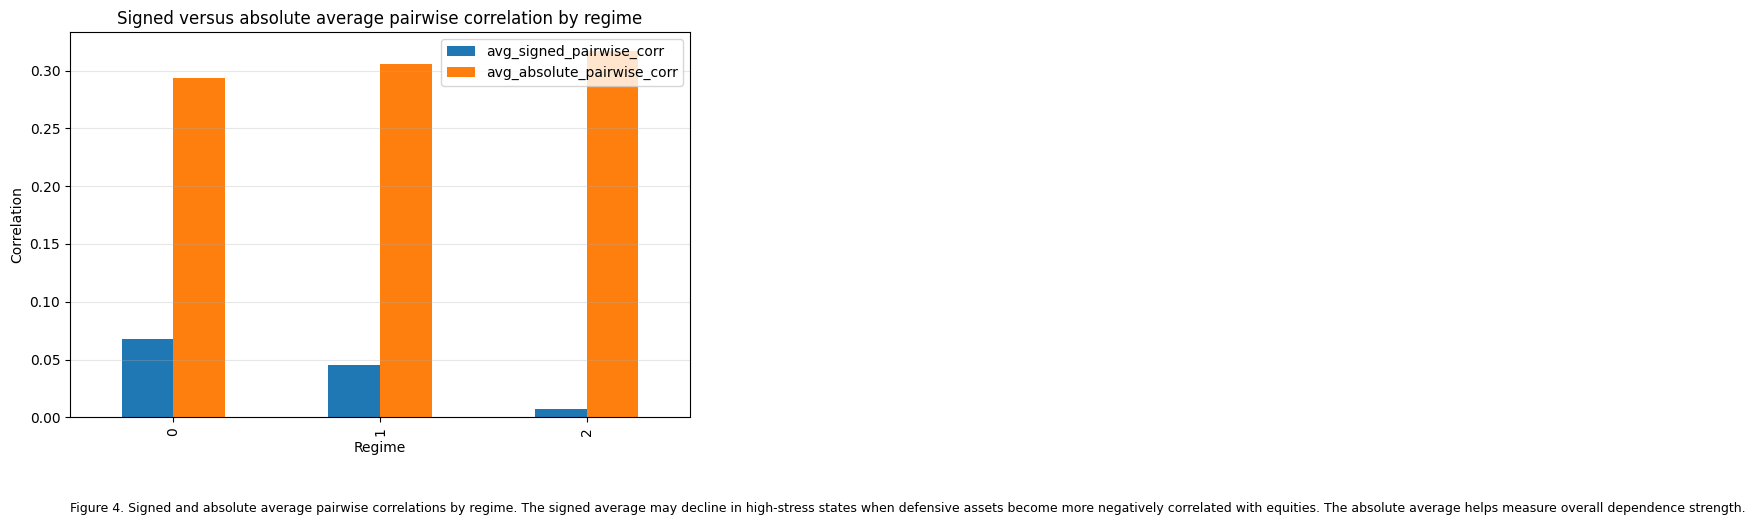

In [14]:
dependence_plot = regime_dependence_summary.set_index("regime")[
    ["avg_signed_pairwise_corr", "avg_absolute_pairwise_corr"]
]

fig, ax = plt.subplots(figsize=(8, 5))

dependence_plot.plot(kind="bar", ax=ax)

ax.set_title("Signed versus absolute average pairwise correlation by regime")
ax.set_xlabel("Regime")
ax.set_ylabel("Correlation")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper right")

caption = (
    "Figure 4. Signed and absolute average pairwise correlations by regime. "
    "The signed average may decline in high-stress states when defensive assets become more negatively "
    "correlated with equities. The absolute average helps measure overall dependence strength."
)

ax.text(
    0.0,
    -0.22,
    caption,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_regime_dependence_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Visual diagnostic — risk metrics by regime

This plot focuses on risk, not alpha.

The key question is whether high-stress regimes exhibit higher volatility, higher CVaR, deeper drawdowns, or higher average correlation.

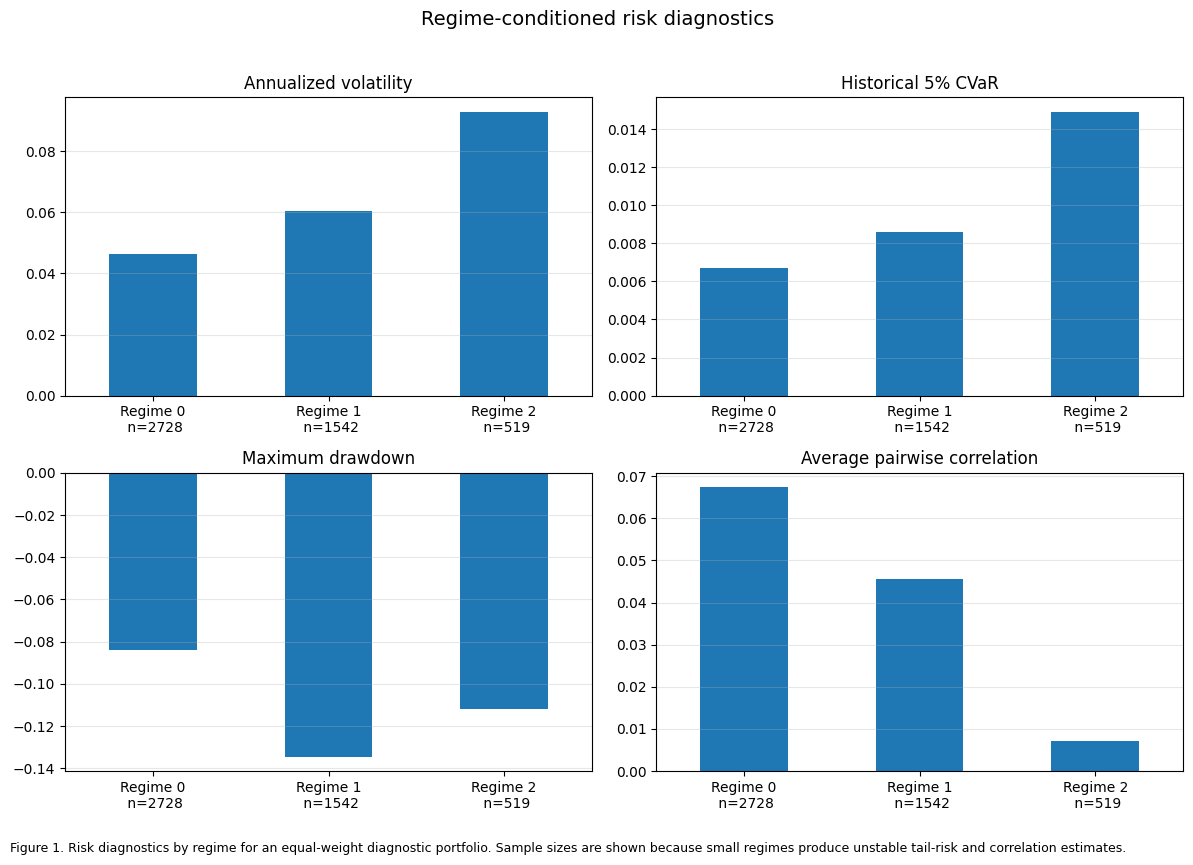

In [9]:
metrics_to_plot = [
    "ann_vol",
    "cvar_5pct",
    "max_drawdown",
    "avg_pairwise_corr",
]

plot_summary = risk_summary.set_index("regime")[metrics_to_plot].copy()

x_labels = [
    f"Regime {int(regime)}\n n={int(regime_counts.loc[regime])}"
    for regime in plot_summary.index
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8),
)

axes = axes.ravel()

metric_titles = {
    "ann_vol": "Annualized volatility",
    "cvar_5pct": "Historical 5% CVaR",
    "max_drawdown": "Maximum drawdown",
    "avg_pairwise_corr": "Average pairwise correlation",
}

for ax, metric in zip(axes, metrics_to_plot):
    plot_summary[metric].plot(kind="bar", ax=ax)
    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.set_xticklabels(x_labels, rotation=0)
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Regime-conditioned risk diagnostics", y=1.02, fontsize=14)

caption = (
    "Figure 1. Risk diagnostics by regime for an equal-weight diagnostic portfolio. "
    "Sample sizes are shown because small regimes produce unstable tail-risk and correlation estimates."
)

fig.text(
    0.01,
    -0.02,
    caption,
    ha="left",
    va="top",
    fontsize=9,
)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_regime_risk_bars.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Visual diagnostic — return distributions by regime

Distribution plots help avoid relying only on summary statistics.

The expected pattern is not necessarily higher average return in calm regimes. The more important question is whether adverse tails become more severe in higher-stress regimes.

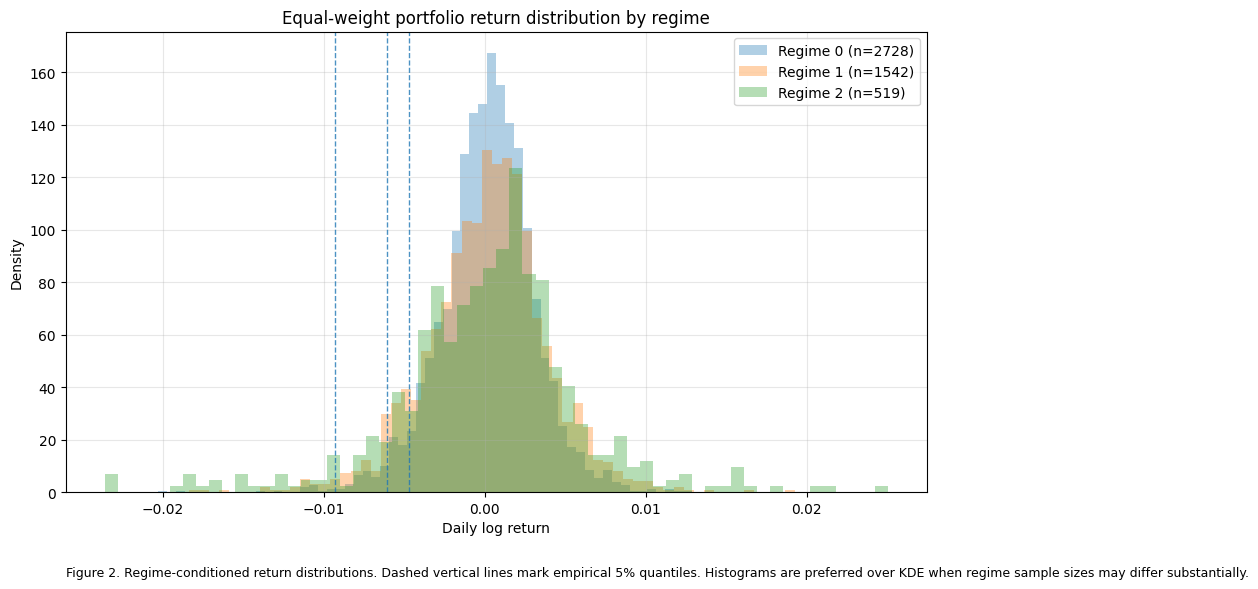

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

for regime in sorted(regime_return_data["regime"].unique()):
    sample = regime_return_data.loc[
        regime_return_data["regime"] == regime,
        "portfolio_return",
    ]

    ax.hist(
        sample,
        bins=60,
        density=True,
        alpha=0.35,
        label=f"Regime {int(regime)} (n={len(sample)})",
    )

    q05 = sample.quantile(0.05)
    ax.axvline(q05, linestyle="--", linewidth=1.0, alpha=0.8)

ax.set_title("Equal-weight portfolio return distribution by regime")
ax.set_xlabel("Daily log return")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.3)
ax.legend()

caption = (
    "Figure 2. Regime-conditioned return distributions. Dashed vertical lines mark empirical 5% quantiles. "
    "Histograms are preferred over KDE when regime sample sizes may differ substantially."
)

ax.text(
    0.0,
    -0.16,
    caption,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_regime_return_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Visual diagnostic — correlation heatmaps

The heatmaps show whether cross-asset dependence changes across regimes.

This is important because a portfolio can become fragile not only because individual assets become more volatile, but also because assets become more correlated.

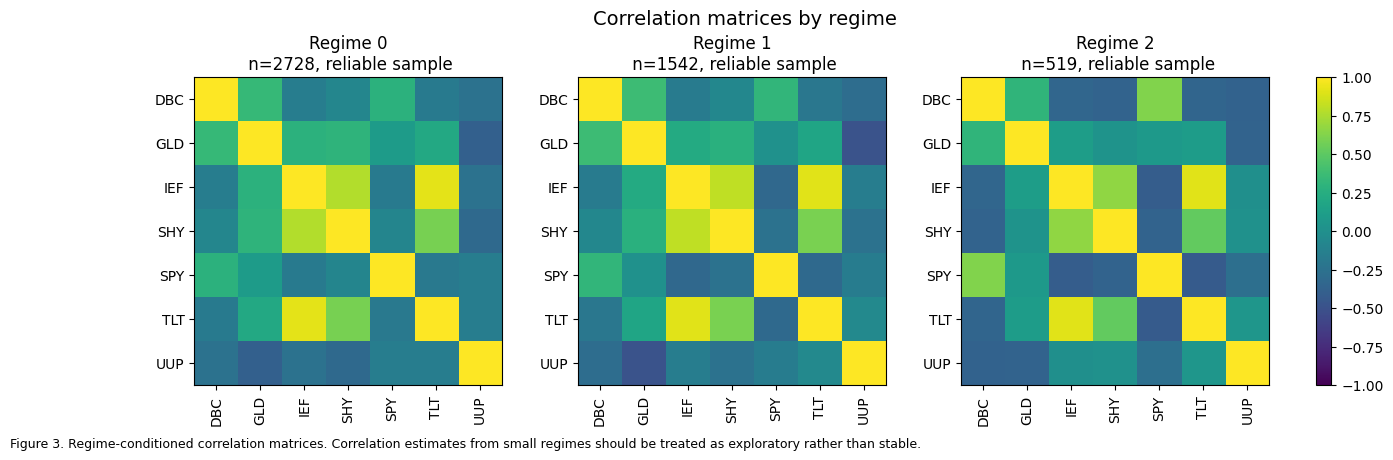

In [11]:
n_regimes = len(correlations)

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_regimes,
    figsize=(5 * n_regimes, 4),
    squeeze=False,
)

axes = axes.ravel()

for ax, regime in zip(axes, sorted(correlations)):
    corr = correlations[regime]
    n_obs = int(regime_counts.loc[regime])
    reliable = n_obs >= MIN_OBS_PER_REGIME

    im = ax.imshow(corr.values, vmin=-1, vmax=1)

    reliability_label = "reliable sample" if reliable else "small sample"
    ax.set_title(f"Regime {int(regime)}\n n={n_obs}, {reliability_label}")

    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.index)

fig.colorbar(im, ax=axes.tolist(), fraction=0.025, pad=0.04)

fig.suptitle("Correlation matrices by regime", y=1.05, fontsize=14)

fig.text(
    0.01,
    -0.02,
    (
        "Figure 3. Regime-conditioned correlation matrices. "
        "Correlation estimates from small regimes should be treated as exploratory rather than stable."
    ),
    ha="left",
    va="top",
    fontsize=9,
)

fig.savefig(FIGURE_DIR / "03_regime_correlation_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Export risk diagnostics

The downstream allocation notebook will use these diagnostics to justify the risk-control design.

The exported long-format covariance and correlation files are easier to inspect and version than nested Python objects.

In [15]:
regime_dependence_summary.to_csv(DATA_DIR / "regime_dependence_summary.csv", index=False)
risk_summary.to_csv(DATA_DIR / "regime_risk_summary.csv", index=False)
regime_label_audit.to_frame().to_csv(DATA_DIR / "regime_label_audit.csv")
regime_sample_reliability.to_csv(DATA_DIR / "regime_sample_reliability.csv")
unconditional_risk_summary.to_csv(DATA_DIR / "unconditional_risk_summary.csv")
regime_return_quantiles.to_csv(DATA_DIR / "regime_return_quantiles.csv")

corr_long = []
for regime, matrix in correlations.items():
    tmp = matrix.stack().rename("correlation").reset_index()
    tmp.columns = ["asset_i", "asset_j", "correlation"]
    tmp["regime"] = regime
    tmp["n_obs"] = int(regime_counts.loc[regime])
    tmp["passes_min_obs_check"] = bool(regime_counts.loc[regime] >= MIN_OBS_PER_REGIME)
    corr_long.append(tmp)

cov_long = []
for regime, matrix in covariances.items():
    tmp = matrix.stack().rename("covariance").reset_index()
    tmp.columns = ["asset_i", "asset_j", "covariance"]
    tmp["regime"] = regime
    tmp["n_obs"] = int(regime_counts.loc[regime])
    tmp["passes_min_obs_check"] = bool(regime_counts.loc[regime] >= MIN_OBS_PER_REGIME)
    cov_long.append(tmp)

corr_long = pd.concat(corr_long, ignore_index=True)
cov_long = pd.concat(cov_long, ignore_index=True)

corr_long.to_csv(DATA_DIR / "regime_correlation_long.csv", index=False)
cov_long.to_csv(DATA_DIR / "regime_covariance_long.csv", index=False)

regime_conditioned_risk_manifest = pd.DataFrame(
    [
        {
            "artifact": "regime_risk_summary.csv",
            "path": str(DATA_DIR / "regime_risk_summary.csv"),
            "rows": risk_summary.shape[0],
            "columns": risk_summary.shape[1],
            "purpose": "Regime-conditioned risk summary for the equal-weight diagnostic portfolio.",
        },
        {
            "artifact": "regime_dependence_summary.csv",
            "path": str(DATA_DIR / "regime_dependence_summary.csv"),
            "rows": regime_dependence_summary.shape[0],
            "columns": regime_dependence_summary.shape[1],
            "purpose": "Signed, absolute, and SPY-relative dependence diagnostics by regime.",
        },
        {
            "artifact": "regime_label_audit.csv",
            "path": str(DATA_DIR / "regime_label_audit.csv"),
            "rows": regime_label_audit.shape[0],
            "columns": 1,
            "purpose": "Fail-fast validation of regime labels loaded from notebook 02.",
        },
        {
            "artifact": "regime_sample_reliability.csv",
            "path": str(DATA_DIR / "regime_sample_reliability.csv"),
            "rows": regime_sample_reliability.shape[0],
            "columns": regime_sample_reliability.shape[1],
            "purpose": "Sample-size reliability checks by regime.",
        },
        {
            "artifact": "unconditional_risk_summary.csv",
            "path": str(DATA_DIR / "unconditional_risk_summary.csv"),
            "rows": unconditional_risk_summary.shape[0],
            "columns": unconditional_risk_summary.shape[1],
            "purpose": "Unconditional equal-weight portfolio risk benchmark.",
        },
        {
            "artifact": "regime_return_quantiles.csv",
            "path": str(DATA_DIR / "regime_return_quantiles.csv"),
            "rows": regime_return_quantiles.shape[0],
            "columns": regime_return_quantiles.shape[1],
            "purpose": "Empirical portfolio-return quantiles by regime.",
        },
        {
            "artifact": "regime_correlation_long.csv",
            "path": str(DATA_DIR / "regime_correlation_long.csv"),
            "rows": corr_long.shape[0],
            "columns": corr_long.shape[1],
            "purpose": "Long-format regime-conditioned correlation estimates.",
        },
        {
            "artifact": "regime_covariance_long.csv",
            "path": str(DATA_DIR / "regime_covariance_long.csv"),
            "rows": cov_long.shape[0],
            "columns": cov_long.shape[1],
            "purpose": "Long-format regime-conditioned annualized covariance estimates.",
        },
    ]
)

regime_conditioned_risk_manifest.to_csv(
    DATA_DIR / "regime_conditioned_risk_manifest.csv",
    index=False,
)

print("Saved:")
print(DATA_DIR / "regime_dependence_summary.csv")
print(DATA_DIR / "regime_risk_summary.csv")
print(DATA_DIR / "regime_label_audit.csv")
print(DATA_DIR / "regime_sample_reliability.csv")
print(DATA_DIR / "unconditional_risk_summary.csv")
print(DATA_DIR / "regime_return_quantiles.csv")
print(DATA_DIR / "regime_correlation_long.csv")
print(DATA_DIR / "regime_covariance_long.csv")
print(DATA_DIR / "regime_conditioned_risk_manifest.csv")

display(regime_conditioned_risk_manifest)

Saved:
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_dependence_summary.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_risk_summary.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_label_audit.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_sample_reliability.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/unconditional_risk_summary.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_return_quantiles.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_correlation_long.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_covariance_long.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_conditioned_risk_manifest.csv


,artifact,path,rows,columns,purpose
0,regime_risk_summary.csv,/workspaces/regime-aware-portfolio-risk-alloca...,3,12,Regime-conditioned risk summary for the equal-...
1,regime_dependence_summary.csv,/workspaces/regime-aware-portfolio-risk-alloca...,3,10,"Signed, absolute, and SPY-relative dependence ..."
2,regime_label_audit.csv,/workspaces/regime-aware-portfolio-risk-alloca...,14,1,Fail-fast validation of regime labels loaded f...
3,regime_sample_reliability.csv,/workspaces/regime-aware-portfolio-risk-alloca...,3,4,Sample-size reliability checks by regime.
4,unconditional_risk_summary.csv,/workspaces/regime-aware-portfolio-risk-alloca...,1,9,Unconditional equal-weight portfolio risk benc...
5,regime_return_quantiles.csv,/workspaces/regime-aware-portfolio-risk-alloca...,3,9,Empirical portfolio-return quantiles by regime.
6,regime_correlation_long.csv,/workspaces/regime-aware-portfolio-risk-alloca...,147,6,Long-format regime-conditioned correlation est...
7,regime_covariance_long.csv,/workspaces/regime-aware-portfolio-risk-alloca...,147,6,Long-format regime-conditioned annualized cova...


## 9. Notebook takeaway

This notebook validates whether the ordered regimes correspond to materially different risk environments.

Main outputs:

- regime-label audit,
- sample-size reliability checks,
- unconditional equal-weight risk benchmark,
- regime-conditioned risk summary,
- regime-conditioned return quantiles,
- regime-conditioned covariance and correlation matrices,
- dependence diagnostics separating signed and absolute correlation effects.

Key interpretation:

1. The regime-label audit passes: all expected regimes are present and each regime has enough observations for first-pass risk diagnostics.
2. Volatility and historical CVaR increase clearly from low-stress to high-stress regimes.
3. Lower-tail quantiles deteriorate in the high-stress regime, supporting the stress-state interpretation.
4. Maximum drawdown is path-dependent and does not need to be monotonic across regimes to validate the regime model.
5. Average signed pairwise correlation can be misleading in a mixed defensive/risky universe. The dependence diagnostics should be read together with the full correlation heatmaps.
6. The regime variable is therefore useful as a risk-conditioning state variable for the allocation notebook.

This notebook does not claim that regimes generate alpha. Its role is to validate the risk relevance of the regime variable before using it in allocation.